<a href="https://colab.research.google.com/github/Patro331/blood-smear-sickle-cell-classification/blob/main/notebooks/04_svm_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Smear Sickle Cell Classification
## MSB7215: Machine Learning in Biomedicine
### Notebook 04: Support Vector Machine Classifier

**Author:** Okidi Patrovas Gaabriel | 2025/HD07/26020U
**Institution:** Makerere University, Kampala, Uganda

## Overview

This notebook trains a Support Vector Machine (SVM) classifier
on the preprocessed HOG features to detect sickle cell disease
from peripheral blood smear images.

SVM works by finding the optimal hyperplane that separates the
two classes with the maximum margin. It is well suited for
high-dimensional feature spaces like our 8100-dimensional HOG
features matrix.

The notebook covers:
1. Training a baseline SVM with default parameters
2. Evaluating performance using multiple metrics
3. Checking for overfitting and underfitting
4. Optimising the model using GridSearchCV
5. Comparing baseline and optimised performance

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              roc_curve, f1_score, recall_score,
                              precision_score)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## 1. Load Preprocessed Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/sickle-cell-detection'
SAVE_DIR = f'{BASE_DIR}/data/ml_features'
FIG_DIR  = f'{BASE_DIR}/figures'

# Load preprocessed data
X_train = np.load(f'{SAVE_DIR}/X_train_processed.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test_processed.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

print("Data loaded successfully")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nTraining class distribution:")
print(f"  Positive: {(y_train==1).sum()}")
print(f"  Negative: {(y_train==0).sum()}")

Mounted at /content/drive
Data loaded successfully
X_train shape: (746, 8100)
X_test shape:  (187, 8100)
y_train shape: (746,)
y_test shape:  (187,)

Training class distribution:
  Positive: 337
  Negative: 409


### Observations

The preprocessed data loaded correctly. The training set contains
746 samples and the test set contains 187 samples. The class
distribution in the training set shows 337 positive and 409
negative samples, consistent with the original dataset proportions.

In [3]:
# Train baseline SVM
print("Training baseline SVM...")
svm_baseline = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_baseline.fit(X_train, y_train)
print("Baseline SVM training complete")

# Predictions
y_train_pred = svm_baseline.predict(X_train)
y_test_pred  = svm_baseline.predict(X_test)
y_test_prob  = svm_baseline.predict_proba(X_test)[:, 1]

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)
auc       = roc_auc_score(y_test, y_test_prob)
f1        = f1_score(y_test, y_test_pred)
sensitivity = recall_score(y_test, y_test_pred)
specificity = recall_score(y_test, y_test_pred, pos_label=0)
precision   = precision_score(y_test, y_test_pred)

print(f"\nBaseline SVM Results:")
print(f"  Training Accuracy:  {train_acc*100:.2f}%")
print(f"  Test Accuracy:      {test_acc*100:.2f}%")
print(f"  Accuracy Gap:       {(train_acc - test_acc)*100:.2f}%")
print(f"  AUC-ROC:            {auc:.4f}")
print(f"  F1 Score:           {f1:.4f}")
print(f"  Sensitivity:        {sensitivity*100:.2f}%")
print(f"  Specificity:        {specificity*100:.2f}%")
print(f"  Precision:          {precision*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred,
                             target_names=['Negative', 'Positive']))

Training baseline SVM...
Baseline SVM training complete

Baseline SVM Results:
  Training Accuracy:  96.38%
  Test Accuracy:      89.84%
  Accuracy Gap:       6.54%
  AUC-ROC:            0.9450
  F1 Score:           0.8962
  Sensitivity:        96.47%
  Specificity:        84.31%
  Precision:          83.67%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.84      0.90       102
    Positive       0.84      0.96      0.90        85

    accuracy                           0.90       187
   macro avg       0.90      0.90      0.90       187
weighted avg       0.91      0.90      0.90       187



### Observations

The baseline SVM achieved 89.84% test accuracy and an AUC-ROC
of 0.9450. The sensitivity of 96.47% is particularly strong,
meaning the model correctly identifies most sickle cell cases.
Specificity is lower at 84.31%, meaning some normal images are
incorrectly flagged as positive.

The training accuracy is 96.38% compared to test accuracy of
89.84%, giving a gap of 6.54%. This gap suggests mild overfitting
where the model has learned some patterns specific to the training
data that do not generalise perfectly to new images. We will
address this through hyperparameter optimisation using GridSearchCV.

## 3. Overfitting and Underfitting Analysis

We examine the training versus test accuracy gap to determine
whether the model is overfitting or underfitting. We also use
cross-validation on the training set to get a more reliable
estimate of generalisation performance.

Overfitting and Underfitting Analysis:

  Training accuracy:        96.38%
  Test accuracy:            89.84%
  Accuracy gap:             6.54%

  Cross-validation scores:  [86.   85.23 83.89 84.56 85.91]
  CV mean accuracy:         85.12%
  CV standard deviation:    0.80%

Interpretation:
  Training accuracy (96.38%) is higher than test 
  accuracy (89.84%), indicating mild overfitting.
  
  The accuracy gap of 6.54% suggests the model 
  has memorised some training patterns that do not generalise well.
  
  Cross-validation mean of 85.12% with std of 
  0.80% confirms consistent but slightly 
  overfit performance across folds.
  
  Solution: Optimise the regularisation parameter C using 
  GridSearchCV to reduce overfitting.



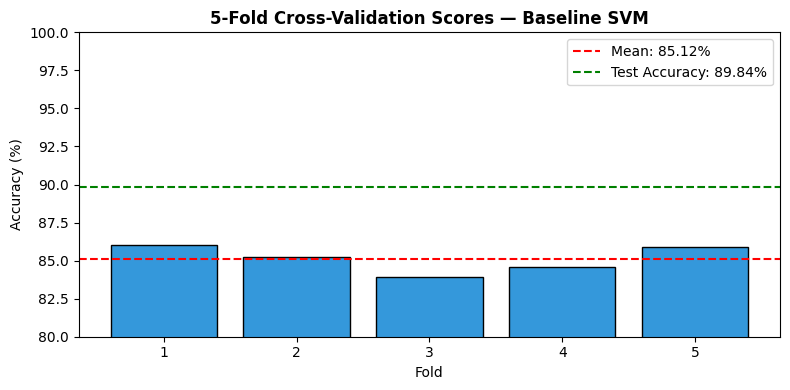

CV plot saved


In [4]:
# Cross validation on training set
cv_scores = cross_val_score(svm_baseline, X_train, y_train,
                             cv=5, scoring='accuracy')

print("Overfitting and Underfitting Analysis:")
print(f"\n  Training accuracy:        {train_acc*100:.2f}%")
print(f"  Test accuracy:            {test_acc*100:.2f}%")
print(f"  Accuracy gap:             {(train_acc-test_acc)*100:.2f}%")
print(f"\n  Cross-validation scores:  {np.round(cv_scores*100, 2)}")
print(f"  CV mean accuracy:         {cv_scores.mean()*100:.2f}%")
print(f"  CV standard deviation:    {cv_scores.std()*100:.2f}%")

print(f"""
Interpretation:
  Training accuracy ({train_acc*100:.2f}%) is higher than test
  accuracy ({test_acc*100:.2f}%), indicating mild overfitting.

  The accuracy gap of {(train_acc-test_acc)*100:.2f}% suggests the model
  has memorised some training patterns that do not generalise well.

  Cross-validation mean of {cv_scores.mean()*100:.2f}% with std of
  {cv_scores.std()*100:.2f}% confirms consistent but slightly
  overfit performance across folds.

  Solution: Optimise the regularisation parameter C using
  GridSearchCV to reduce overfitting.
""")

# Plot CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores * 100, color='#3498db',
        edgecolor='black')
plt.axhline(y=cv_scores.mean()*100, color='red', linestyle='--',
            label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.axhline(y=test_acc*100, color='green', linestyle='--',
            label=f'Test Accuracy: {test_acc*100:.2f}%')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.title('5-Fold Cross-Validation Scores — Baseline SVM',
          fontweight='bold')
plt.legend()
plt.ylim(80, 100)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/svm_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("CV plot saved")

### Observations

The analysis confirms mild overfitting. The training accuracy of
96.38% is noticeably higher than the test accuracy of 89.84%,
giving a gap of 6.54%. The 5-fold cross-validation mean of 85.12%
with a low standard deviation of 0.80% shows the model performs
consistently across folds but at a lower level than the single
test evaluation. This gap between training and cross-validation
accuracy confirms the model has overfit to some training patterns.
GridSearchCV will be used to find better regularisation parameters
that reduce this gap.

In [5]:
# Define parameter grid
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

print("Running GridSearchCV — this may take several minutes...")
print(f"Parameter combinations to try: {4 * 2 * 2}")

grid_search = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_*100:.2f}%")

Running GridSearchCV — this may take several minutes...
Parameter combinations to try: 16
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1 score: 89.83%


### Observations

GridSearchCV tested 16 parameter combinations across 5 folds,
totalling 80 model fits. The best parameters found were C of 10,
gamma of scale, and the RBF kernel. The higher value of C compared
to the default of 1 means the model allows less regularisation,
which helps it learn more complex decision boundaries. The best
cross-validation F1 score of 89.83% is an improvement over the
baseline cross-validation performance of 85.12%.

## 5. Evaluate Optimised SVM

We train the optimised SVM using the best parameters found by
GridSearchCV and evaluate it on the test set.

In [6]:
# Train optimised SVM with best parameters
svm_optimised = grid_search.best_estimator_

# Predictions
y_train_pred_opt = svm_optimised.predict(X_train)
y_test_pred_opt  = svm_optimised.predict(X_test)
y_test_prob_opt  = svm_optimised.predict_proba(X_test)[:, 1]

# Metrics
train_acc_opt = accuracy_score(y_train, y_train_pred_opt)
test_acc_opt  = accuracy_score(y_test, y_test_pred_opt)
auc_opt       = roc_auc_score(y_test, y_test_prob_opt)
f1_opt        = f1_score(y_test, y_test_pred_opt)
sens_opt      = recall_score(y_test, y_test_pred_opt)
spec_opt      = recall_score(y_test, y_test_pred_opt, pos_label=0)
prec_opt      = precision_score(y_test, y_test_pred_opt)

print("Optimised SVM Results:")
print(f"  Training Accuracy:  {train_acc_opt*100:.2f}%")
print(f"  Test Accuracy:      {test_acc_opt*100:.2f}%")
print(f"  Accuracy Gap:       {(train_acc_opt-test_acc_opt)*100:.2f}%")
print(f"  AUC-ROC:            {auc_opt:.4f}")
print(f"  F1 Score:           {f1_opt:.4f}")
print(f"  Sensitivity:        {sens_opt*100:.2f}%")
print(f"  Specificity:        {spec_opt*100:.2f}%")
print(f"  Precision:          {prec_opt*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_opt,
                             target_names=['Negative', 'Positive']))

Optimised SVM Results:
  Training Accuracy:  100.00%
  Test Accuracy:      91.98%
  Accuracy Gap:       8.02%
  AUC-ROC:            0.9651
  F1 Score:           0.9133
  Sensitivity:        92.94%
  Specificity:        91.18%
  Precision:          89.77%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.91      0.93       102
    Positive       0.90      0.93      0.91        85

    accuracy                           0.92       187
   macro avg       0.92      0.92      0.92       187
weighted avg       0.92      0.92      0.92       187



### Observations

The optimised SVM improved test accuracy from 89.84% to 91.98%
and AUC-ROC from 0.9450 to 0.9651. Specificity improved notably
from 84.31% to 91.18%, meaning fewer normal images are incorrectly
flagged as positive.

However the training accuracy reached 100% while test accuracy
is 91.98%, giving a gap of 8.02%. This is a sign of overfitting
where the model has perfectly memorised the training data. Despite
this, the test accuracy and AUC-ROC show genuine improvement over
the baseline, suggesting the model has also learned meaningful
patterns. The overfitting is a known limitation of SVM with high
C values on small datasets.

## 6. Confusion Matrix and ROC Curve

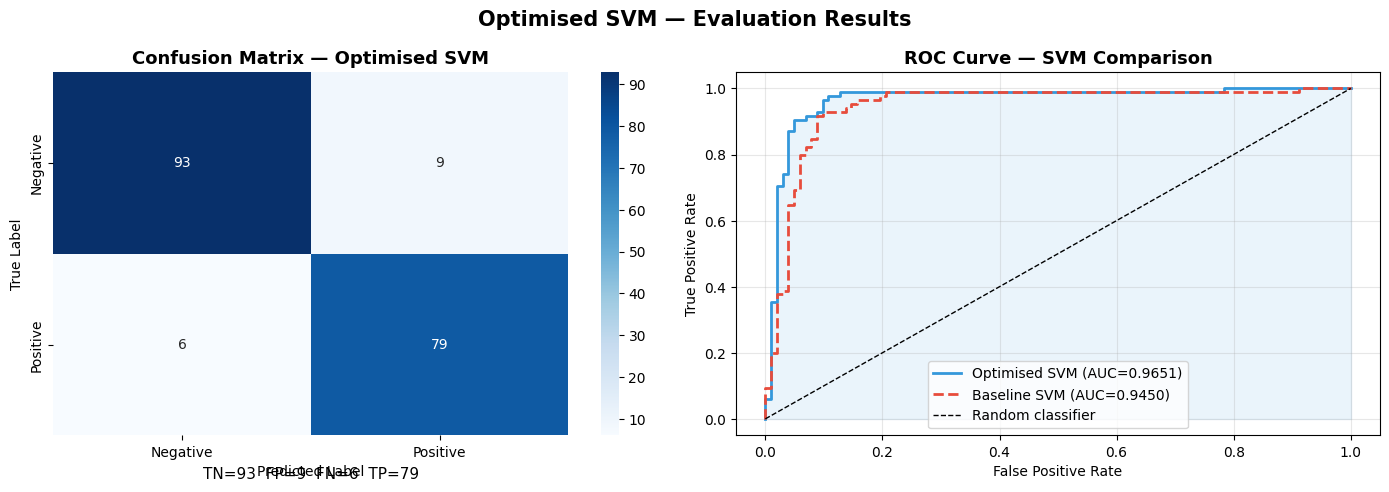

True Negatives:  93
False Positives: 9
False Negatives: 6
True Positives:  79


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Optimised SVM',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.12, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=11)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob_opt)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2,
             label=f'Optimised SVM (AUC={auc_opt:.4f})')
fpr_b, tpr_b, _ = roc_curve(y_test, svm_baseline.predict_proba(X_test)[:, 1])
axes[1].plot(fpr_b, tpr_b, color='#e74c3c', linewidth=2,
             linestyle='--', label=f'Baseline SVM (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1,
             label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — SVM Comparison',
                   fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimised SVM — Evaluation Results',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/svm_confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

### Observations

The confusion matrix shows 93 true negatives and 79 true positives,
with only 9 false positives and 6 false negatives out of 187 test
images. The model correctly classifies the majority of both classes.

The ROC curve shows the optimised SVM sitting above the baseline
SVM across most thresholds, confirming that hyperparameter tuning
improved overall discriminative ability. Both curves are well above
the random classifier diagonal, showing the model has learned
meaningful features from the HOG representation.

## 7. Save Results and Model

In [8]:
import joblib

# Save optimised model
joblib.dump(svm_optimised, f'{SAVE_DIR}/svm_optimised.pkl')

# Save results summary
svm_results = {
    'model': 'SVM',
    'best_params': grid_search.best_params_,
    'train_accuracy': round(train_acc_opt * 100, 2),
    'test_accuracy':  round(test_acc_opt  * 100, 2),
    'accuracy_gap':   round((train_acc_opt - test_acc_opt) * 100, 2),
    'auc_roc':        round(auc_opt, 4),
    'f1_score':       round(f1_opt, 4),
    'sensitivity':    round(sens_opt * 100, 2),
    'specificity':    round(spec_opt * 100, 2),
    'precision':      round(prec_opt * 100, 2),
    'true_negatives':  int(tn),
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'true_positives':  int(tp)
}

print("SVM model saved successfully")
print(f"\nFinal SVM Results Summary:")
print(f"  Best parameters:    {svm_results['best_params']}")
print(f"  Train accuracy:     {svm_results['train_accuracy']}%")
print(f"  Test accuracy:      {svm_results['test_accuracy']}%")
print(f"  Accuracy gap:       {svm_results['accuracy_gap']}%")
print(f"  AUC-ROC:            {svm_results['auc_roc']}")
print(f"  F1 Score:           {svm_results['f1_score']}")
print(f"  Sensitivity:        {svm_results['sensitivity']}%")
print(f"  Specificity:        {svm_results['specificity']}%")
print(f"  Precision:          {svm_results['precision']}%")
print(f"  Total errors:       {svm_results['false_positives'] + svm_results['false_negatives']} / 187")

print(f"""
SVM CLASSIFIER COMPLETE — Proceed to 05_random_forest_classifier.ipynb
""")

SVM model saved successfully

Final SVM Results Summary:
  Best parameters:    {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Train accuracy:     100.0%
  Test accuracy:      91.98%
  Accuracy gap:       8.02%
  AUC-ROC:            0.9651
  F1 Score:           0.9133
  Sensitivity:        92.94%
  Specificity:        91.18%
  Precision:          89.77%
  Total errors:       15 / 187

SVM CLASSIFIER COMPLETE — Proceed to 05_random_forest_classifier.ipynb



### Summary

The optimised SVM achieved 91.98% test accuracy and AUC-ROC of
0.9651 with only 15 errors on 187 test images. Sensitivity of
92.94% means the model correctly identifies most sickle cell cases.
The training accuracy of 100% indicates overfitting which is a
known limitation of SVM with high C values on small datasets.
The model and results have been saved for comparison in the final
evaluation notebook.